# Self-consistent solution of the Dyson equation using the Discrete Lehman Representation

The goal of this tutorial is to showcase the use of the discrete Lehmann representation (DLR) to solve the Dyson equation self-consistently (i.e., given an expression for the self-energy in terms of the Green's function). The first exercise will implement a simple self-consistent loop for the Sachdev-Ye-Kitaev (SYK) model, and the second exercise will implement a DMFT calculation using the iterated perturbation theory (IPT) approximation. For background on the DLR and its use in TRIQS, we refer to the [TRIQS documentation](https://triqs.github.io/triqs/latest/userguide/python/tutorials/Basics/solutions/01s-Greens_functions.html#Compact-meshes-for-imaginary-time-/-frequency:-DLR-Green%E2%80%99s-function).

<!-- If you are interested in more of the theory behind this method,a good first reference is [(here)](https://doi.org/10.1103/PhysRevB.86.085133), which this tutorial follows closely. --> 

<!-- ## Discrete Lehman Representation
Here we take advantage of the spectral representation of the Green's function
\begin{equation}
G(\tau)=-\int_{-\infty}^{\infty} K(\tau, \omega) \rho(\omega) d \omega
\end{equation}
with the fermionic kernel being given by 
\begin{equation}
K(\tau, \omega)=\frac{e^{-\omega \tau}}{1+e^{-\beta \omega}}
\end{equation}
The kernel $K$ can be approximated by a low rank decomposition. This has some negative consequences, such as the ill-conditioning of analytic continuation (which you make have seen in the Pade approximates used in previous tutorials), but it also has some benefits. This behaviour can be exploited to provide a compact representation of $G$. 
\begin{equation}
G(\tau) \approx G_{\mathrm{DLR}}(\tau)=\sum_{k=1}^r \frac{e^{-\omega_k \tau}}{1+e^{-\omega_k}} \widehat{g}_k=\sum_{k=1}^r \widetilde{g}_k e^{-\omega_k \tau}
\end{equation} -->

### Constructing DLR Green's Functions

We begin by setting various parameters, building a DLR imaginary frequency mesh, and creating Green's function and self-energy containers from this mesh. The DLR parameters are the desired accuracy, `dlr_error`, and the problem bandwidth or frequency cutoff, `w_max`. We also set some physical problem parameters, as well as a maximum number of iterations for the self-consistency, a self-consistency convergence tolerance, and a mixing parameter $\alpha$.

In [86]:
from triqs.gf import *
from triqs.gf.tools import *
from triqs.operators import *
from triqs.gf.block_gf import *
from triqs.gf.descriptors import Function
import h5
import numpy as np
from triqs.plot.mpl_interface import *
import matplotlib.pyplot as plt
import matplotlib as mpl
import json, sys, os

params = {
    "beta": 500.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 5.0,
    "dlr_err": 1e-8, 
    "J" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

gf_struct =[('up',1), ('dn',1)]
iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)
G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
G_tau = make_gf_dlr_imtime(G_iw)
Sigma_iw = G_iw.copy()
Sigma_tau = make_gf_dlr_imtime(Sigma_iw)

### Exercise 1 
We first solve the $O+1$-dimensional (impurity) Sachdev-Ye-Kitaev (SYK) model self-consistently. The Hamiltonian is given by 
$$H = \sum^N_{ijkl} J_{ijkl} c^\dagger_i c^\dagger_j c_k c_l$$
where the $J_{ijkl}$ are random Gaussian couplings between $N$ fermions with constant variance $J^2$.
 This model has many interesting applications for non-Fermi liquids, or strange metals, and quantum criticality. You can read more about the model and its extensions [(here)](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.94.035004). Here we are interested in a simple form of the self-energy in the large-$N$ limit of the model, given by
\begin{equation}
\Sigma(\tau) = -J^2 G^2(\tau)G(-\tau).
\end{equation}
Combining this self-energy with the Dyson equation yields a self-consistent set of equations. These were solved using the DLR with weighted fixed point iteration in Sec. VII of [(this paper)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.105.235115). Following that reference, it is your turn to write a self-consistent loop to solve for $G$.

As shown in the paper, as we approach the $\beta = \infty$ limit, the result should begin to match the conformal solution of these equations. Try comparing to the conformal solution! We should already have quite good agreement at $\beta = 1000$.
\begin{equation}
G_c(\tau)=-\frac{\pi^{1 / 4}}{\sqrt{2 \beta}}\left(\sin \left(\frac{\pi \tau}{\beta}\right)\right)^{-1 / 2}
\end{equation}

In [87]:
G_iw << SemiCircular(1.0)           # Initial guess for the Green's function  
G_tau << make_gf_dlr_imtime(G_iw)   # Initial guess in the imaginary time domain
error = 1.0
iter = 0

while error > params["threshold"]:
    for block, g in G_tau:
        Sigma_tau[block].data[:,0,0] = params["J"]**2 * g.data[:,0,0]**2*np.flip(g.data[:,0,0]) # Compute self-energy in imaginary time

    Sigma_iw << make_gf_dlr_imfreq(Sigma_tau)                                       # Transform self-energy to Matsubara frequency domain 

    for block, g in G_tau:
        G_iw[block] << inverse(iOmega_n - Sigma_iw[block])                          # Solve the Dyson equation to obtain Green's function
    G_old = G_tau.copy()
    G_tau << params["alpha"]*G_old + (1-params["alpha"])*make_gf_dlr_imtime(G_iw)   # Update Green's function via weighted fixed point iteration
    error = np.max(np.abs((G_tau["up"].data[:,0,0] - G_old["up"].data[:,0,0])))     # Compute absolute error
    iter += 1

    # Print iteration number and error
    print("Iteration:", iter, "Error:", error)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 1 Error: 0.18620720598844637
Iteration: 2 Error: 0.09591885627788482
Iteration: 3 Error: 0.04688903710401063
Iteration: 4 Error: 0.006693699864808944
Iteration: 5 Error: 0.0006500289998440656
Iteration: 6 Error: 0.00015572355093314283
Iteration: 7 Error: 2.5976909072987497e-05
Iteration: 8 Error: 7.100638501164602e-06
Iteration: 9 Error: 1.9008486006680259e-06
Iteration: 10 Error: 7.498470171729554e-07
Iteration: 11 Error: 3.250232031917766e-07
Iteration: 12 Error: 1.5666570055833384e-07
Iteration: 13 Error: 7.775264952714107e-08
Iteration: 14 Error: 3.821340015253169e-08
Iteration: 15 Error: 1.9576569268440893e-08
Iteration: 16 Error: 9.662122907373015e-09


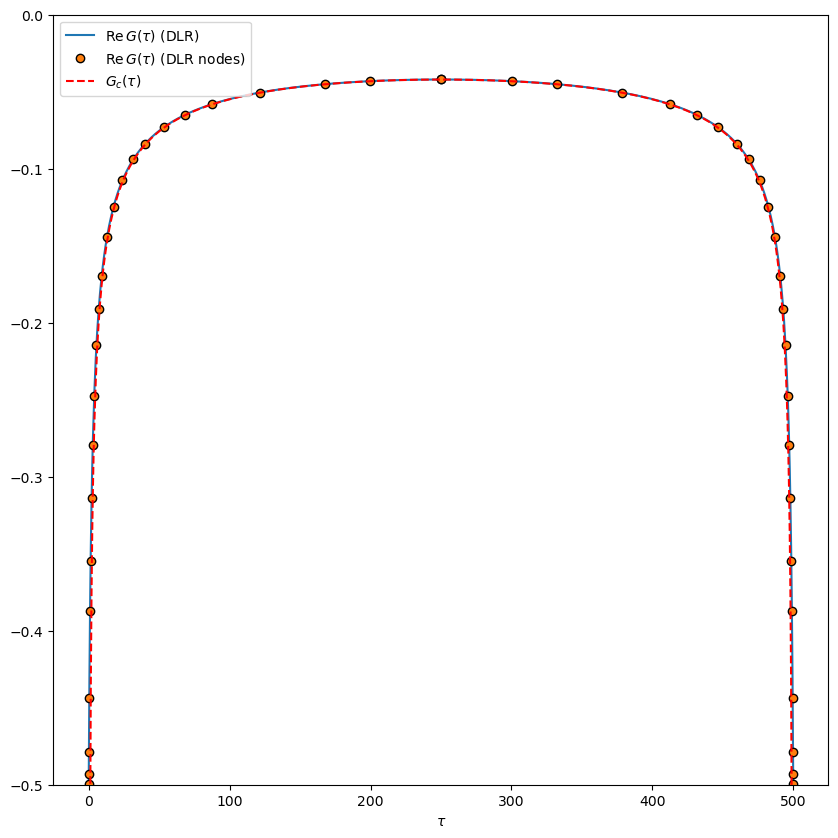

In [88]:
G_tau_dense = make_gf_imtime(G_tau["up"], n_tau=1000)                           # Obtain DLR expansion on dense grid
t =  np.array([x.real for x in G_tau_dense.mesh.values()])[1:]                  # Obtain dense grid
Gconformal = -np.pi**(1/4) / np.sqrt(2*params["beta"]) * 1/np.sqrt(np.sin(np.pi * t / params["beta"]))    # Conformal solution

plt.figure(figsize = (10,10))
oplot(G_tau_dense.real, label = r"$\mathrm{Re}\, G(\tau)$ (DLR)")
oplot(G_tau["up"].real, marker = "o", markeredgecolor = "black", label = r"$\mathrm{Re}\, G(\tau)$ (DLR nodes)")
plt.plot(t, Gconformal, label = r"$G_c(\tau)$", color = "red", linestyle = "dashed")
plt.ylim(-0.5,0)
plt.ylabel("")
plt.legend(loc="upper left")
plt.show()

Note that in this case, the Green's function is purely real. We observe a slight discrepancy with the conformal solution at the endpoints (which is expected---see the reference). You can experiment with increasing $\beta$ (it might be necessary to increase the mixing parameter $\alpha$ in order to converge), and should observe even closer agreement with the conformal solution. We can also plot the self-energy in Matsubara frequency, which is purely imaginary:

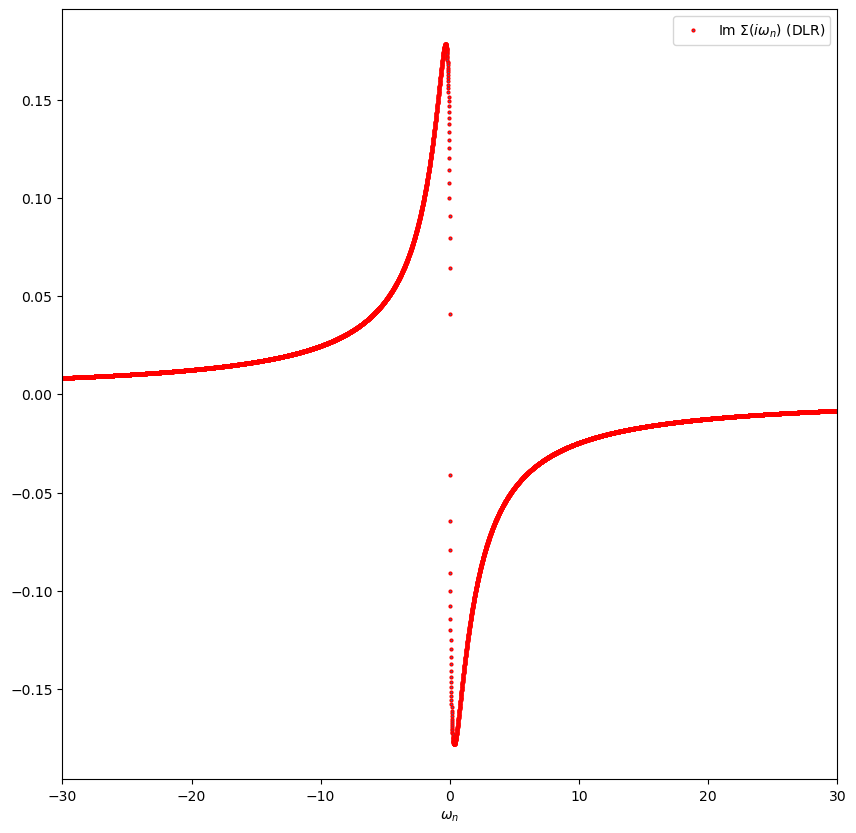

In [79]:
Sigma_iw_dense = make_gf_imfreq(Sigma_iw["up"], n_iw = 5000)

plt.figure(figsize = (10,10))
oplot(Sigma_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $\Sigma(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()

### Exercise 2 

Next try repeating Tutorial 1 to converge the IPT equations for a given $\beta$ and $U$. Check how much quicker your calculations are compared to Tutorial 1.


In [ ]:

from triqs.gf import *
import numpy as np
from triqs.operators import *

class IPTSolver:
    def __init__(self, params):
        self.params = params
        # Matsubara frequency Green's functions
        iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G_iw = BlockGf(mesh=iw_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G0_iw = self.G_iw.copy() # self.G0 will be set by the user after initialization
        self.Sigma_iw = self.G_iw.copy()

        # Imaginary time
        tau_mesh = MeshDLRImTime(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps =params["dlr_err"], symmetrize = True)
        self.G0_tau = BlockGf(mesh=tau_mesh, gf_struct = [('up',1), ('dn',1)] )
        self.G_tau = self.G0_tau.copy()
        self.Sigma_tau = self.G0_tau.copy()

    def solve(self):
        error = 1.0
        iter = 0

        
            


In [ ]:
params = {
    "beta": 50.0,
    "mu": 0.0,
    "alpha" : 0.5,
    "w_max": 10.0,
    "dlr_err": 1e-8, 
    "U" : 3.0, # In the Mott state, U > 4, you run into trouble, but this is also why the IPT tutorial just stops at small iteration number. 
    "t" : 1.0,
    "max_iter": 1000, # small iteration number is ~ 25
    "threshold": 1e-8,
}

In [ ]:
S = IPTSolver(params)
S.G_iw << SemiCircular(2*params["t"])


Green Function G composed of 2 blocks: 
 Greens Function G_up with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 
 Greens Function G_dn with mesh DLR imfreq mesh of size 36 with beta = 50, statistic = Fermion, w_max = 10, eps = 1e-08 and target_shape (1, 1): 
 

In [ ]:
error = 1.0
iter = 0
while error > params["threshold"]:
    print("Iteration:", iter)
    for block, g in S.G0_iw:
        g << inverse( iOmega_n - params["t"]**2 * S.G_iw[block] )
    S.G0_tau << make_gf_dlr_imtime(S.G0_iw)
    S.Sigma_tau << (params["U"]**2) * S.G0_tau * S.G0_tau * S.G0_tau
    S.Sigma_iw << make_gf_dlr_imfreq(S.Sigma_tau)
    G_old = S.G_iw.copy()
    S.G_iw << inverse(inverse(S.G0_iw) - S.Sigma_iw)
    S.G_iw << params["alpha"]*S.G_iw+ (1-params["alpha"])*G_old
    G_tau_old = S.G_tau.copy()
    S.G_tau << make_gf_dlr_imtime(S.G_iw)
    error = np.mean(np.abs((S.G_tau["up"].real.data[:,0,0] - G_tau_old["up"].real.data[:,0,0]) / G_tau_old["up"].real.data[:,0,0]))

    iter += 1
    if iter % 5 == 0:
        print(error, iter)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
0.0016821665998838229 5
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
3.707673734909233e-05 10
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
8.68261338822299e-07 15
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
2.081733772436832e-08 20
Iteration: 20


/tmp/ipykernel_109476/735204175.py:15: RuntimeWarning: divide by zero encountered in divide
  error = np.mean(np.abs((S.G_tau["up"].real.data[:,0,0] - G_tau_old["up"].real.data[:,0,0]) / G_tau_old["up"].real.data[:,0,0]))


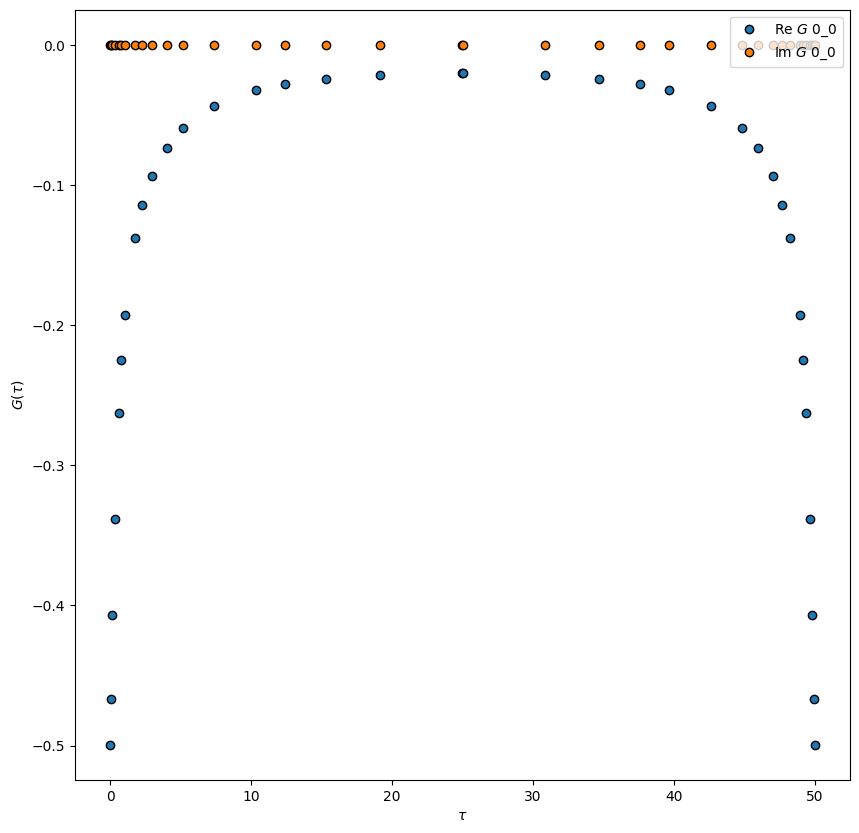

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.G_tau["up"], marker = "o", markeredgecolor = "black", name = r"$G$")
plt.show()

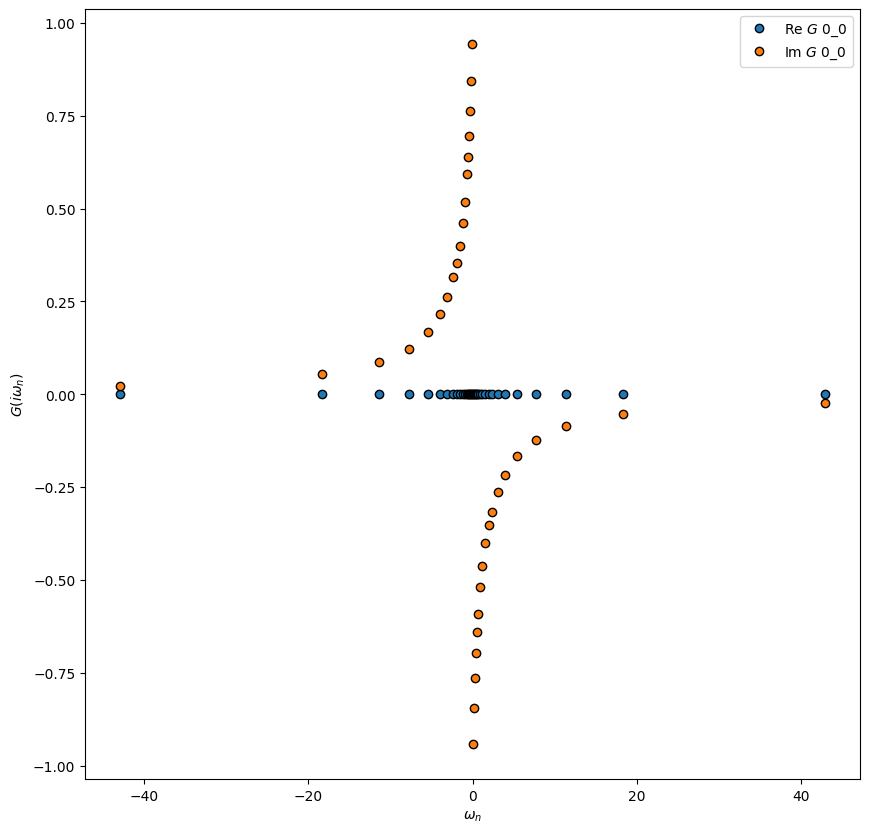

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.G_iw["up"], marker = "o", markeredgecolor = "black", name = r"$G$")
plt.show()

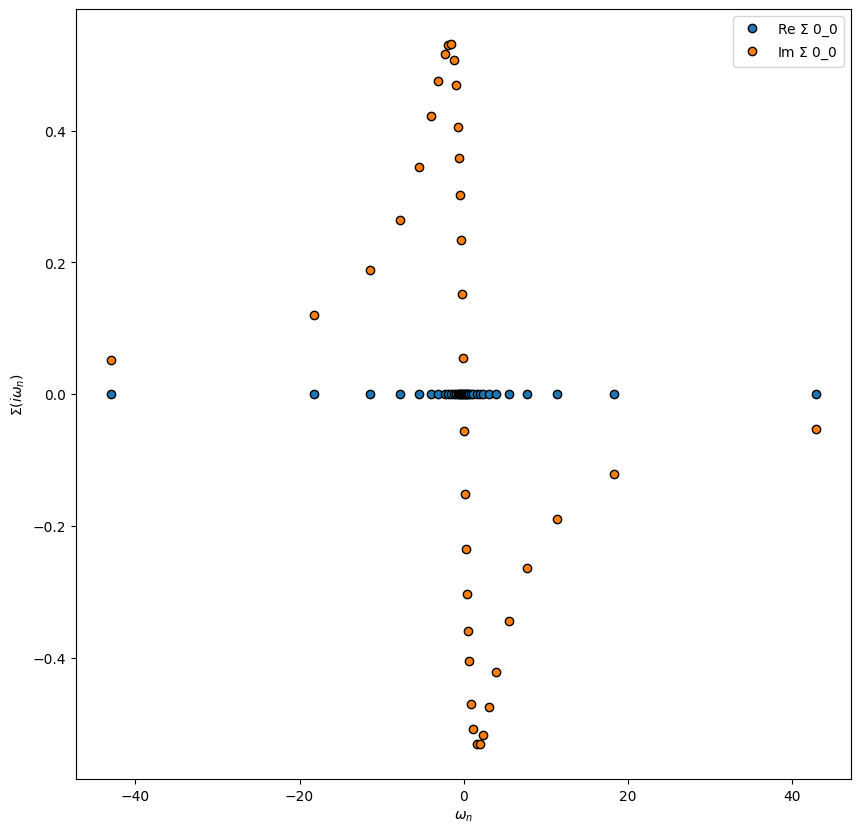

In [ ]:
plt.figure(figsize = (10,10))
oplot(S.Sigma_iw["up"], marker = "o", markeredgecolor = "black", name = r"$\Sigma$")
plt.show()

In [ ]:
G_w = Gf(mesh=MeshReFreq(window = (-5.0,5.0), n_w=1000), target_shape=[1,1])
G_iw = make_gf_imfreq(S.G_iw["up"], n_iw = 2**14+3)
G_w.set_from_pade(G_iw, 100, 0.01)

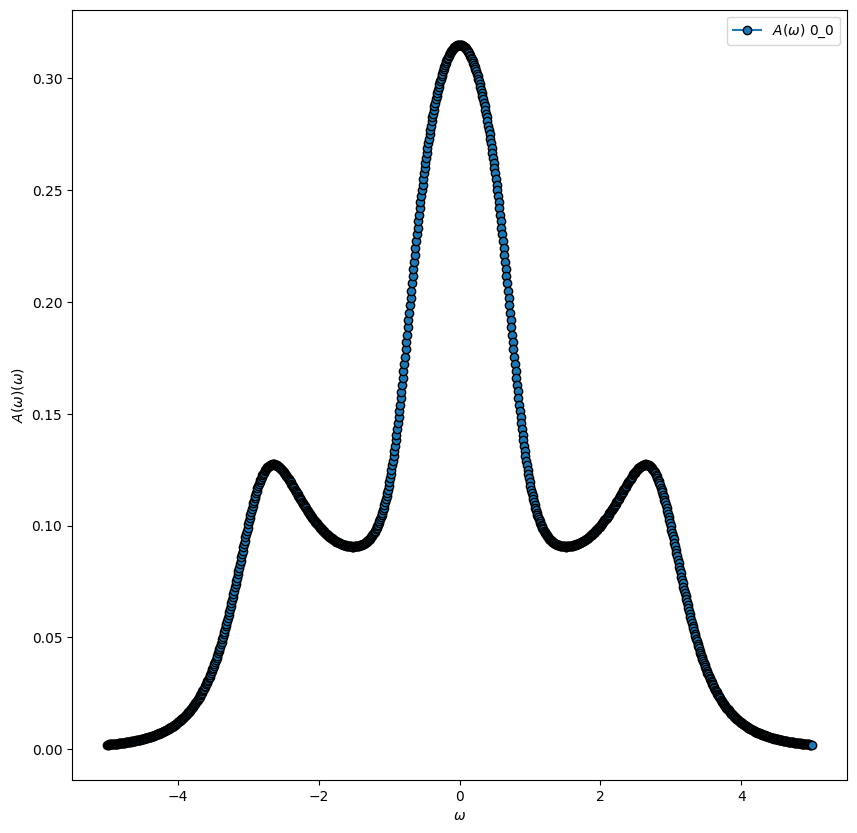

In [ ]:
plt.figure(figsize = (10,10))
oplot(-np.imag(G_w)/np.pi, marker = "o", markeredgecolor = "black", name = r"$A(\omega)$")
plt.show()